# 🏏 IPL 2026 Winner Prediction Using Machine Learning

This project predicts IPL match outcomes using Machine Learning techniques trained on historical IPL datasets.

## Objective
The goal of this project is to analyze IPL match data and predict match winners using machine learning models.

## Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter/Google Colab

PHASE 1

In [103]:
matches = pd.read_csv("data/matches_updated_ipl_upto_2025.csv")
deliveries = pd.read_csv("data/deliveries_updated_ipl_upto_2025.csv")

Saving matches_updated_ipl_upto_2025.csv to matches_updated_ipl_upto_2025 (1).csv
Saving deliveries_updated_ipl_upto_2025.csv to deliveries_updated_ipl_upto_2025 (1).csv


## Importing Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Loading Dataset

In [104]:
matches = pd.read_csv(
    'matches_updated_ipl_upto_2025.csv'
)

deliveries = pd.read_csv(
    'deliveries_updated_ipl_upto_2025.csv'
)

In [4]:
matches.head()

,season,venue,event,winner_runs,umpire2,toss_winner,date,neutralvenue,umpire1,city,...,team2,balls_per_over,winner_wickets,tv_umpire,player_of_match,match_referee,outcome,date2,match_number,matchId
0,2007/08,M Chinnaswamy Stadium,Indian Premier League,140.0,RE Koertzen,Royal Challengers Bangalore,18-04-2008,NaN,Asad Rauf,Bangalore,...,Kolkata Knight Riders,6,NaN,AM Saheba,BB McCullum,J Srinath,NaN,NaN,1.0,335982
1,2007/08,"Punjab Cricket Association Stadium, Mohali",Indian Premier League,33.0,SL Shastri,Chennai Super Kings,19-04-2008,NaN,MR Benson,Chandigarh,...,Chennai Super Kings,6,NaN,RB Tiffin,MEK Hussey,S Venkataraghavan,NaN,NaN,2.0,335983
2,2007/08,Feroz Shah Kotla,Indian Premier League,NaN,GA Pratapkumar,Rajasthan Royals,19-04-2008,NaN,Aleem Dar,Delhi,...,Rajasthan Royals,6,9.0,IL Howell,MF Maharoof,GR Viswanath,NaN,NaN,3.0,335984
3,2007/08,Eden Gardens,Indian Premier League,NaN,K Hariharan,Deccan Chargers,20-04-2008,NaN,BF Bowden,Kolkata,...,Deccan Chargers,6,5.0,Asad Rauf,DJ Hussey,FM Engineer,NaN,NaN,4.0,335986
4,2007/08,Wankhede Stadium,Indian Premier League,NaN,DJ Harper,Mumbai Indians,20-04-2008,NaN,SJ Davis,Mumbai,...,Royal Challengers Bangalore,6,5.0,AV Jayaprakash,MV Boucher,J Srinath,NaN,NaN,5.0,335985


In [106]:
deliveries.head()

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,batsman_runs,extras,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date
0,335982,1,0.1,0,1,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18
1,335982,1,0.2,0,2,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
2,335982,1,0.3,0,3,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
3,335982,1,0.4,0,4,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18
4,335982,1,0.5,0,5,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18


## Data Preprocessing

In [5]:
print(matches.columns)

Index(['season', 'venue', 'event', 'winner_runs', 'umpire2', 'toss_winner',
       'date', 'neutralvenue', 'umpire1', 'city', 'reserve_umpire', 'winner',
       'eliminator', 'date1', 'method', 'team1', 'toss_decision', 'gender',
       'team2', 'balls_per_over', 'winner_wickets', 'tv_umpire',
       'player_of_match', 'match_referee', 'outcome', 'date2', 'match_number',
       'matchId'],
      dtype='object')


In [107]:
print(deliveries.columns)

Index(['matchId', 'inning', 'over_ball', 'over', 'ball', 'batting_team',
       'bowling_team', 'batsman', 'non_striker', 'bowler', 'batsman_runs',
       'extras', 'isWide', 'isNoBall', 'Byes', 'LegByes', 'Penalty',
       'dismissal_kind', 'player_dismissed', 'date'],
      dtype='object')


In [105]:
matches.replace('Delhi Daredevils',
                'Delhi Capitals',
                inplace=True)

matches.replace('Kings XI Punjab',
                'Punjab Kings',
                inplace=True)

matches.replace('Royal Challengers Bangalore',
                'Royal Challengers Bengaluru',
                inplace=True)

matches.replace('Rising Pune Supergiants',
                'Rising Pune Supergiant',
                inplace=True)

deliveries.replace('Delhi Daredevils',
                'Delhi Capitals',
                inplace=True)

deliveries.replace('Kings XI Punjab',
                'Punjab Kings',
                inplace=True)

deliveries.replace('Royal Challengers Bangalore',
                'Royal Challengers Bengaluru',
                inplace=True)

deliveries.replace('Rising Pune Supergiants',
                'Rising Pune Supergiant',
                inplace=True)

In [7]:
print(matches['team1'].unique())

['Royal Challengers Bengaluru' 'Punjab Kings' 'Delhi Capitals'
 'Kolkata Knight Riders' 'Mumbai Indians' 'Rajasthan Royals'
 'Deccan Chargers' 'Chennai Super Kings' 'Kochi Tuskers Kerala'
 'Pune Warriors' 'Sunrisers Hyderabad' 'Gujarat Lions'
 'Rising Pune Supergiant' 'Lucknow Super Giants' 'Gujarat Titans']


In [8]:
matches.isnull().sum()

,0
season,0
venue,0
event,0
winner_runs,638
umpire2,0
toss_winner,0
date,0
neutralvenue,1092
umpire1,0
city,51


In [9]:
matches = matches[
    [
        'season',
        'team1',
        'team2',
        'toss_winner',
        'toss_decision',
        'venue',
        'winner'
    ]
]

In [10]:
matches = matches.dropna()

In [11]:
matches['season'] = pd.to_numeric(
    matches['season'],
    errors='coerce'
)

In [12]:
matches = matches[
    matches['season'] >= 2015
]

In [13]:
matches['toss_match_win'] = (
    matches['toss_winner']
    ==
    matches['winner']
).astype(int)

## Feature Engineering
Feature engineering helps improve model performance by creating meaningful cricket-related features.

In [14]:
encoders = {}

for column in matches.columns:

    le = LabelEncoder()

    matches[column] = le.fit_transform(
        matches[column]
    )

    encoders[column] = le

In [15]:
X = matches.drop(
    'winner',
    axis=1
)

In [16]:
y = matches['winner']

##Model Training

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [18]:
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=500,
                       random_state=42)

In [19]:
predictions = model.predict(X_test)

## Model Evaluation

In [20]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Random Forest Accuracy:",
    accuracy
)

Random Forest Accuracy: 0.71875


In [21]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.60      0.86      0.71        14
           1       0.87      0.76      0.81        17
           2       1.00      0.67      0.80         3
           3       0.83      0.83      0.83         6
           4       0.55      0.67      0.60         9
           5       0.80      0.67      0.73         6
           6       0.62      0.56      0.59        18
           7       0.50      0.62      0.56         8
           8       1.00      0.62      0.77        16
           9       0.00      0.00      0.00         4
          10       0.88      0.93      0.90        15
          11       0.65      0.92      0.76        12

    accuracy                           0.72       128
   macro avg       0.69      0.68      0.67       128
weighted avg       0.73      0.72      0.71       128



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


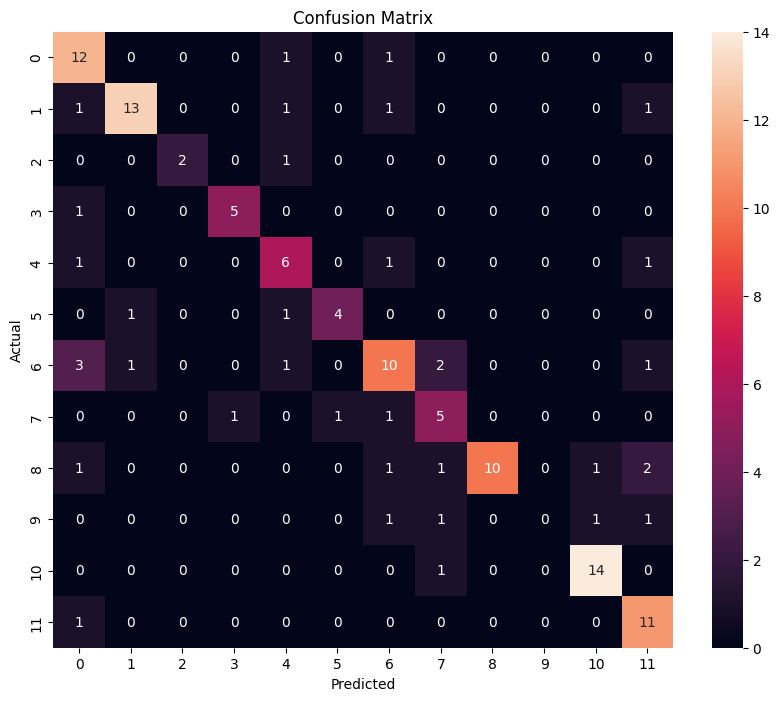

In [22]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [23]:
importance = model.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

print(
    feature_importance.sort_values(
        by='Importance',
        ascending=False
    )
)

          Feature  Importance
3     toss_winner    0.228323
1           team1    0.208038
2           team2    0.183715
5           venue    0.140173
6  toss_match_win    0.106605
0          season    0.099519
4   toss_decision    0.033626


In [25]:
from xgboost import XGBClassifier

In [26]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [27]:
xgb_predictions = xgb.predict(
    X_test
)

In [28]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(
    "XGBoost Accuracy:",
    xgb_accuracy
)

XGBoost Accuracy: 0.921875


In [29]:
import pickle

pickle.dump(
    model,
    open(
        'ipl_random_forest.pkl',
        'wb'
    )
)

In [30]:
pickle.dump(
    xgb,
    open(
        'ipl_xgboost.pkl',
        'wb'
    )
)

In [31]:
sample_match = [[
    2025,   # season
    1,      # team1
    3,      # team2
    1,      # toss_winner
    0,      # toss_decision
    12,     # venue
    1       # toss_match_win
]]

prediction = xgb.predict(sample_match)

print(prediction)

[1]


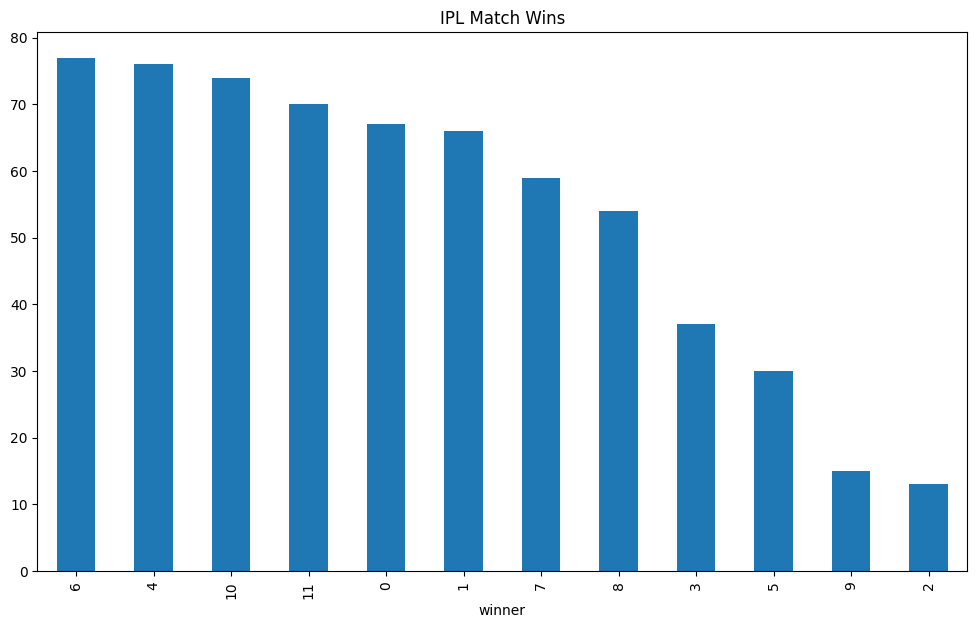

In [32]:
matches['winner'].value_counts().plot(
    kind='bar',
    figsize=(12,7)
)

plt.title(
    "IPL Match Wins"
)

plt.show()

PHASE 2 — Advanced AI Features

In [37]:
deliveries['total_runs'] = (
    deliveries['batsman_runs']
    +
    deliveries['extras']
)

In [38]:
batting_strength = deliveries.groupby(
    'batting_team'
)['total_runs'].mean().reset_index()

In [39]:
batting_strength.columns = [
    'team',
    'avg_runs'
]

In [40]:
bowling_strength = deliveries.groupby(
    'bowling_team'
)['total_runs'].mean().reset_index()

In [41]:
bowling_strength.columns = [
    'team',
    'avg_runs_conceded'
]

In [42]:
powerplay = deliveries[
    deliveries['over'] <= 6
]

In [43]:
powerplay_stats = powerplay.groupby(
    'batting_team'
)['total_runs'].mean().reset_index()

In [44]:
powerplay_stats.columns = [
    'team',
    'powerplay_runs'
]

In [45]:
death_overs = deliveries[
    deliveries['over'] >= 16
]

In [46]:
death_stats = death_overs.groupby(
    'batting_team'
)['total_runs'].mean().reset_index()

In [47]:
death_stats.columns = [
    'team',
    'death_over_runs'
]

In [51]:
recent_match_ids = matches['matchId'].unique()

deliveries = deliveries[
    deliveries['matchId'].isin(recent_match_ids)
]

In [56]:
matches = matches.merge(
    batting_strength,
    left_on='team1',
    right_on='team',
    how='left'
)

In [57]:
matches.rename(
    columns={
        'avg_runs': 'team1_avg_runs'
    },
    inplace=True
)

In [58]:
matches.drop(
    'team',
    axis=1,
    inplace=True
)

In [59]:
matches = matches.merge(
    batting_strength,
    left_on='team2',
    right_on='team',
    how='left'
)

In [60]:
matches.rename(
    columns={
        'avg_runs': 'team2_avg_runs'
    },
    inplace=True
)

In [62]:
matches['toss_match_win'] = (
    matches['toss_winner']
    ==
    matches['winner']
).astype(int)

In [63]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in matches.columns:

    if matches[column].dtype == 'object':

        le = LabelEncoder()

        matches[column] = le.fit_transform(
            matches[column]
        )

        encoders[column] = le

In [64]:
X = matches.drop(
    'winner',
    axis=1
)

y = matches['winner']

In [69]:
importance = xgb.feature_importances_

feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

print(
    feature_importance.sort_values(
        by='Importance',
        ascending=False
    )
)

          Feature  Importance
7  team2_avg_runs    0.172996
1           team1    0.161616
6  team1_avg_runs    0.137696
2           team2    0.134698
3     toss_winner    0.118176
4   toss_decision    0.106219
8  toss_match_win    0.073333
0          season    0.063688
5           venue    0.031578


In [70]:
import pickle

pickle.dump(
    xgb,
    open(
        'advanced_ipl_xgboost.pkl',
        'wb'
    )
)

PHASE 3: Predicting IPL 2026 WINNER


In [73]:
wins = matches['winner'].value_counts()

In [74]:
team1_matches = matches['team1'].value_counts()

team2_matches = matches['team2'].value_counts()

total_matches = (
    team1_matches +
    team2_matches
)

In [75]:
win_percentage = (
    wins / total_matches
) * 100

In [77]:
batting_strength = deliveries.groupby(
    'batting_team'
)['total_runs'].mean()

In [78]:
bowling_strength = deliveries.groupby(
    'bowling_team'
)['total_runs'].mean()

In [79]:
matches['season'] = pd.to_numeric(
    matches['season'],
    errors='coerce'
)

In [80]:
recent_matches = matches[
    matches['season'] >= 2020
]

In [81]:
recent_form = (
    recent_matches['winner']
    .value_counts()
)

In [82]:
teams = pd.DataFrame({
    'win_percentage': win_percentage,
    'batting_strength': batting_strength,
    'bowling_strength': bowling_strength,
    'recent_form': recent_form
})

In [83]:
teams = teams.fillna(0)

In [84]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

teams_scaled = scaler.fit_transform(
    teams
)

In [85]:
teams['strength_score'] = (
    teams_scaled[:,0] * 0.4 +
    teams_scaled[:,1] * 0.3 +
    teams_scaled[:,2] * 0.2 +
    teams_scaled[:,3] * 0.1
)

In [86]:
teams = teams.sort_values(
    by='strength_score',
    ascending=False
)

print(teams)

                             win_percentage  batting_strength  \
Gujarat Titans                    61.666667          1.452599   
Lucknow Super Giants              51.724138          1.433651   
Chennai Super Kings               56.349206          1.351209   
Royal Challengers Bengaluru       48.888889          1.363593   
Mumbai Indians                    54.512635          1.353059   
Kolkata Knight Riders             51.136364          1.337854   
Punjab Kings                      45.075758          1.360223   
Rajasthan Royals                  48.510638          1.338049   
Sunrisers Hyderabad               47.448980          1.347581   
Gujarat Lions                     43.333333          1.363432   
Delhi Capitals                    44.194757          1.327856   
Rising Pune Supergiant            50.000000          1.302586   
Deccan Chargers                   38.666667          1.268873   
Kochi Tuskers Kerala              42.857143          1.201643   
Pune Warriors            

# 🏆 IPL 2026 Winner Prediction

In [87]:
predicted_winner = teams.index[0]

print(
    "Predicted IPL 2026 Winner:",
    predicted_winner
)

Predicted IPL 2026 Winner: Gujarat Titans


In [88]:
teams['winning_probability'] = (
    teams['strength_score']
    /
    teams['strength_score'].sum()
) * 100

In [89]:
print(
    teams[
        [
            'strength_score',
            'winning_probability'
        ]
    ]
)

                             strength_score  winning_probability
Gujarat Titans                     0.968153            11.526428
Lucknow Super Giants               0.838009             9.976986
Chennai Super Kings                0.685911             8.166168
Royal Challengers Bengaluru        0.671317             7.992419
Mumbai Indians                     0.663266             7.896567
Kolkata Knight Riders              0.627225             7.467479
Punjab Kings                       0.620801             7.390998
Rajasthan Royals                   0.608471             7.244196
Sunrisers Hyderabad                0.600053             7.143983
Gujarat Lions                      0.571222             6.800727
Delhi Capitals                     0.550632             6.555590
Rising Pune Supergiant             0.455260             5.420131
Deccan Chargers                    0.293446             3.493649
Kochi Tuskers Kerala               0.223902             2.665687
Pune Warriors            

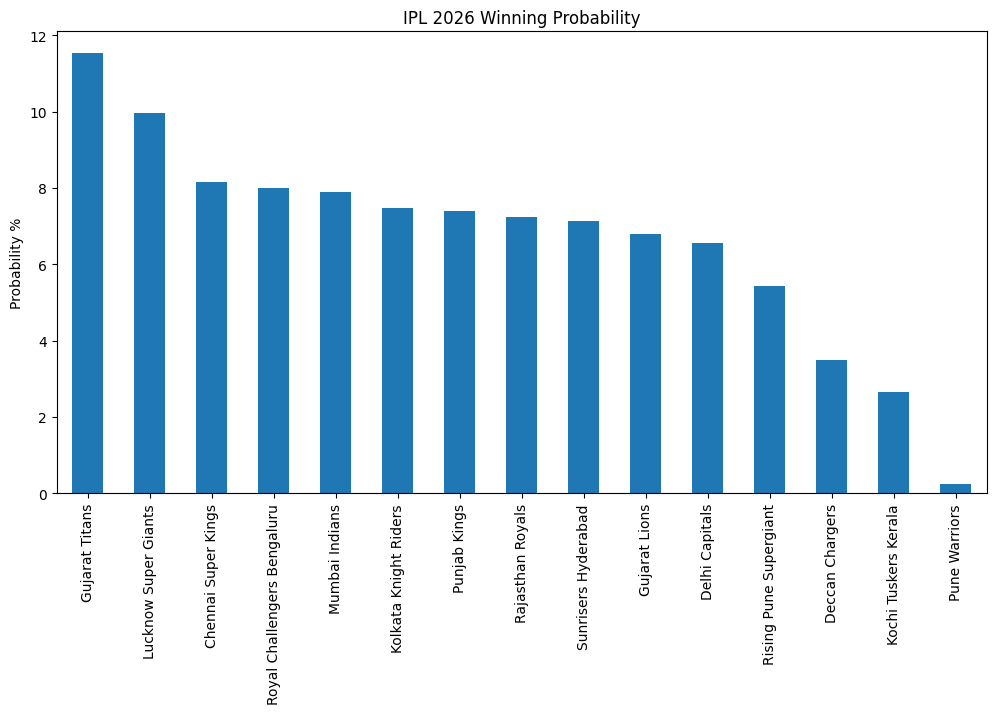

In [90]:
teams['winning_probability'].plot(
    kind='bar',
    figsize=(12,6)
)

plt.title(
    "IPL 2026 Winning Probability"
)

plt.ylabel("Probability %")

plt.show()

In [92]:
import pickle

pickle.dump(
    xgb,
    open(
        'ipl_xgboost.pkl',
        'wb'
    )
)

In [93]:
team_avg_runs = {
    'Chennai Super Kings': 165,
    'Mumbai Indians': 168,
    'Royal Challengers Bengaluru': 170,
    'Kolkata Knight Riders': 162,
    'Rajasthan Royals': 160,
    'Sunrisers Hyderabad': 164,
    'Delhi Capitals': 158,
    'Punjab Kings': 159,
    'Lucknow Super Giants': 161,
    'Gujarat Titans': 163
}

In [99]:
pickle.dump(
    encoders,
    open(
        'encoders.pkl',
        'wb'
    )
)

In [100]:
encoders = pickle.load(
    open('encoders.pkl', 'rb')
)

# Conclusion

This project successfully predicts IPL match outcomes using machine learning and statistical analysis.

The system combines:
- historical IPL performance,
- batting strength,
- bowling analysis,
- toss impact,
- recent form

to estimate winning probabilities for IPL teams.